In [1]:
#판다스, 넘파이, 맷플롯

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


#사이킷런 데이터셋 자체 가져옴
from sklearn import datasets

In [4]:
data = datasets.load_iris()        #임포트한 값부터 주소 찍기

#특징, 답 (X,features Y,labels)
X, Y = data.data, data.target

##K-means clustering

In [6]:
#군집화

from sklearn.cluster import KMeans


#객체 생성
#옵션 (n_cluster = k 정하기, max_iter = 대장 옮기기 반복횟수)
km = KMeans(n_clusters = 3, max_iter = 10)

#훈련
km.fit(X)       #비지도니까


#예측
km_pred = km.predict(X)


#평가


In [8]:
for i in range(len(Y)):
    print(Y[i], 'vs', km_pred[i])           #  y는 본 데이터에 있는 답 vs km예측치 i번 반복 : 답 맞춰본 꼴
                                                    #문제: 군집 알고리즘은 0 = 0으로 그룹핑한지 모름 서로의 그룹핑 네임이 안 맞는 것 시각화 단계로 확인해야한다

0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
0 vs 1
1 vs 0
1 vs 2
1 vs 0
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 0
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
1 vs 2
2 vs 0
2 vs 2
2 vs 0
2 vs 0
2 vs 0
2 vs 0
2 vs 2
2 vs 0
2 vs 0
2 vs 0
2 vs 0
2 vs 0
2 vs 0
2 vs 2
2 vs 2
2 vs 0
2 vs 0
2 vs 0
2 vs 0
2 vs 2
2 vs 0
2 vs 2
2 vs 0
2 vs 2
2 vs 0
2 vs 0
2 vs 2
2 vs 2
2 vs 0
2 vs 0
2 vs 0
2 vs 0
2 vs 0
2 vs 2
2 vs 0
2 vs 0
2 vs 0
2 vs 0
2 vs 2
2 vs 0
2 vs 0
2 vs 0
2 vs 2

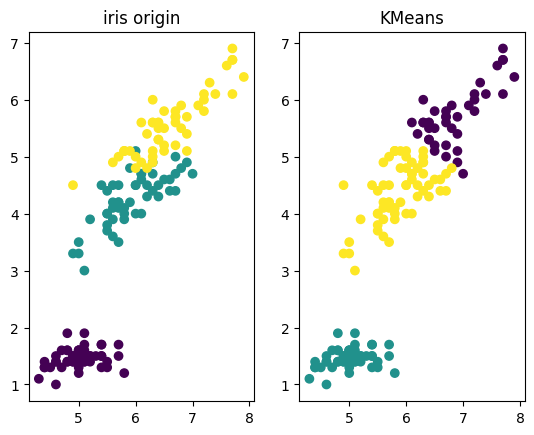

In [19]:
X = pd.DataFrame(X)
Y = pd.DataFrame(Y)
df = pd.concat([X,Y], axis = 1)



df.head()

#시각화: 색으로 그룹을 나타낸다
#특징 개수: 4=> 4차원 그래프로 구현, 데이터 일부만 선택 2차원으로 시각화. (차원 축소와는 다름 이는 새로운 데이터를 만들어서 차원을 축소하는 것)

#임의로 2차원만 선택해서 그림
x = df.iloc[:,0]    # 열 값은 의미 없음, 위치만 확인하는 것
y = df.iloc[:,2]    # 위 동일
c = df.iloc[:,4]    # 어떤 그룹에 속했는지 정답을 표시함. 그룹을 컬러화

#답안 그림 추가
c1 = km_pred


#왼쪽 정답지, 오른쪽 kmeans답안
fig, ax = plt.subplots(1,2)

ax[0].scatter(x,y,c=c)                  #정답지 시각화
ax[0].set_title('iris origin')          #범례 넣고싶다 아오
ax[1].scatter(x,y,c=c1)
ax[1].set_title('KMeans')
plt.show()

# 엘보우 그래프 활용

In [26]:
#클러스터링을 3개로 설정했고 정답도 3개임, 과연 이 분류가 맞는지? 최적의 군집 개수 찾기 = 엘보우 그래프


#1.그림 그려볼 군집의 개수
scope = range(1,10)     #1개 군집일때부터 9개 군집일때까지 거리 계산을 하겠다

#군집의 개수가 변할 때마다의 군집 내 거리 계산 결과 담음 (작을수록 좋음)
inertia = []


#군집 1개일 때, 2개일때,, 9개일때까지 각 모델을 훈련시켜 군집 내의 거리(inertias) 저장.

for k in scope:
    model = KMeans(n_clusters=k)
    model.fit(X)
    print(model.inertia_)
    inertia.append(model.inertia_)            #model.inertia_:군집이 k개 일때 군집 내 거리

681.3705999999996
152.34795176035797
78.85566582597727
57.28235929288103
46.47223015873018
42.75028694654457
35.93706779331783
36.757119995501576
28.700988165819695


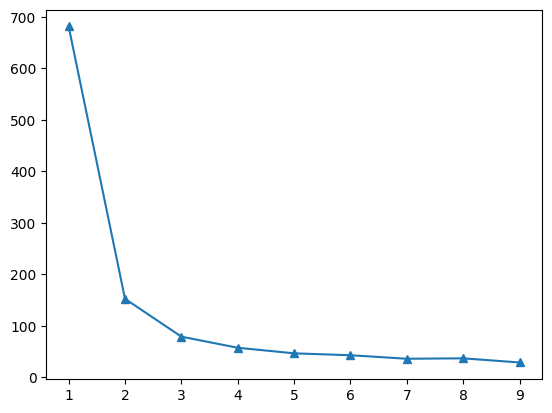

In [29]:
#선 그랲(군집 개수, 거리 / 옵션은 값에 점 찍어주고 모양은 '^')
plt.plot(scope,inertia, marker = '^')
plt.show()      #위의 그룹 프린팅 결과의 시각화, 엘보 포인트는 급격히 줄어드는 것의 마지막 정도?

## 실루엣 계수 계산

In [30]:
from sklearn.metrics import silhouette_score

#KMeans 실루엣 계수 계산

score = silhouette_score(X,km_pred)     #X와 그룹핑 결과 비교후 계산해줌

print(f'k-means의 실루엣 계수는 {score:.2f}입니다.')

k-means의 실루엣 계수는 0.55입니다.


# DBSCAN

In [32]:
#옵션

#eps: 주변 반경, min_samples: 기준 데이터 수(반경 내 얼마나)

from sklearn.cluster import DBSCAN

data = datasets.load_iris()
X = data.data
Y = data.target


db = DBSCAN(eps = 0.5, min_samples=3)
db.fit(X)
#오류:db_pred = db.predict(X) 일때 predict 안됨. fit_predict 사용
db_pred = db.fit_predict(X)

db_score = silhouette_score(X, db_pred)
print(f'DBSCAN의 실루엣 계수는 {db_score:.2f}입니다.')          #KMeans 와 비교했을 때 왜 안 좋아졌게: iris 데이터 특징임

DBSCAN의 실루엣 계수는 0.35입니다.


#군집화 - > 답 없는 상황에서 특징을 추출해서 임의로 그룹핑하는 것에 의의

 - 그룹핑을 평가: 실루엣 계수
 - 몇 개로 그룹핑이 적절한가? : 엘보우 그래프


In [37]:
#달 모양 만들기 데이터셋    #데이터 개수, 노이즈 = 달 모양에서 좀 벗어나쇼
X, Y = datasets.make_moons(n_samples = 250, noise = 0.1)

In [39]:
X[0] #X데이터 셋의 행 출력. 그 행 안에 있는 0,1번 열 조회 결과

array([-0.14653065,  0.99250783])

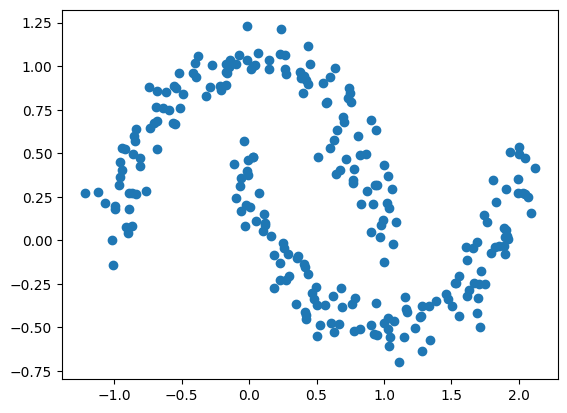

In [38]:
#시각화
            #X축, Y축
plt.scatter(X[:,0], X[:,1])
plt.show()

##KMeans와 DBSCAN 적용해보기


In [47]:
#KMeans 객체 생성, 훈련, 예측


from sklearn.cluster import KMeans
km = KMeans(n_clusters=2)

km.fit(X)

km_pred = km.predict(X)

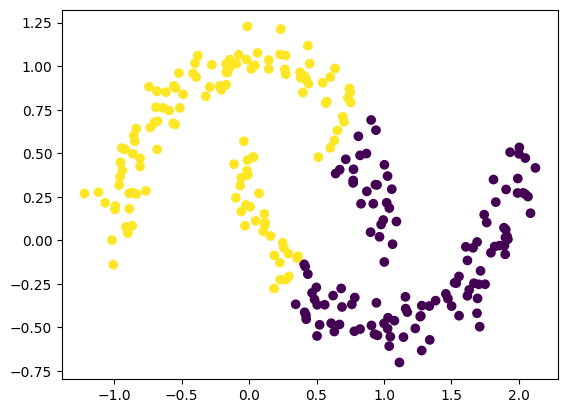

In [48]:
#KMeans 시각화

#데이터 프레임화, x축, y축 설정, 그래프 그리기? 꼭 안해도 되는듯

plt.scatter(X[:,0],X[:, 1], c=km_pred)
plt.show()

In [49]:
#KMeans 실루엣 계수

km_score = silhouette_score(X,km_pred)
print(f'KMeans 실루엣 계수: {km_score:.2f}')

KMeans 실루엣 계수: 0.48


In [ ]:
#옵션

#eps: 주변 반경, min_samples: 기준 데이터 수(반경 내 얼마나)

from sklearn.cluster import DBSCAN

data = datasets.load_iris()
X = data.data
Y = data.target


db = DBSCAN(eps = 0.5, min_samples=3)
db.fit(X)
#오류:db_pred = db.predict(X) 일때 predict 안됨. fit_predict 사용
db_pred = db.fit_predict(X)

db_score = silhouette_score(X, db_pred)
print(f'DBSCAN의 실루엣 계수는 {db_score:.2f}입니다.')          #KMeans 와 비교했을 때 왜 안 좋아졌게: iris 데이터 특징임

## DESCAN 연습
- 오류가 나는 이유
:  반경, 최소 이웃 수


- 반경 조정 = 덩어리 크기 조정
- 최소 이웃 수 조정 = 덩어리 규모 조정

In [63]:
#DBSCAN
#객체 생성, 훈련, 예측

from sklearn.cluster import DBSCAN

db = DBSCAN(eps = 0.2, min_samples=3)
db.fit(X)
db_pred = db.fit_predict(X)

print(db_pred)  #결과가 0으로만 나옴, 비교군이 없다는 뜻 해결: 반경 옵션 조정


[0 1 1 1 1 0 1 0 1 0 1 0 1 0 0 0 1 0 1 0 1 0 1 1 1 1 0 1 0 0 0 0 1 0 0 1 1
 1 1 0 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 0 0 1 0 0 0 0 1 0 1 1 1 0 1 0 0 0 1
 1 0 0 1 0 1 0 1 0 0 1 0 0 0 0 1 0 0 1 0 0 1 1 0 0 1 0 0 1 0 0 1 1 1 1 0 0
 0 0 0 0 1 1 1 1 0 0 0 0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 1 0 0 0 1 0 1 1 0 1 0
 1 0 1 0 1 1 1 0 0 1 1 1 0 1 0 0 0 1 1 0 0 1 1 0 1 1 0 0 0 0 1 1 1 0 1 1 0
 0 1 0 1 0 0 1 0 0 1 0 0 1 1 1 1 1 0 0 1 0 1 0 1 1 0 0 0 1 0 1 0 1 0 0 0 1
 1 0 1 1 1 1 0 1 1 1 1 1 1 1 0 1 0 0 0 0 1 1 1 1 0 1 0 1]


In [64]:
#실루엣 계수

db_score = silhouette_score(X, db_pred)
print(f'DBSCAN 실루엣 계수: {db_score:.2f}')

DBSCAN 실루엣 계수: 0.32


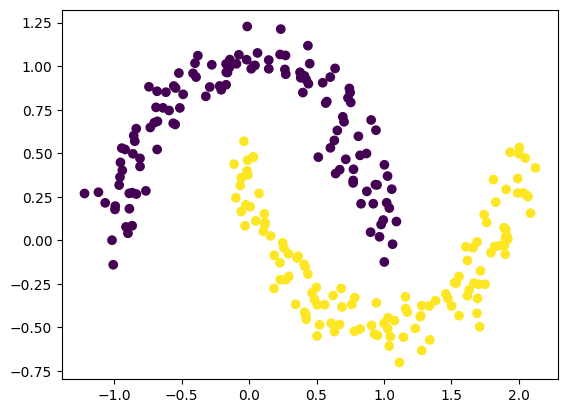

In [65]:
#시각화

plt.scatter(X[:,0], X[:,1], c = db_pred)
plt.show()

# 비교 시각화

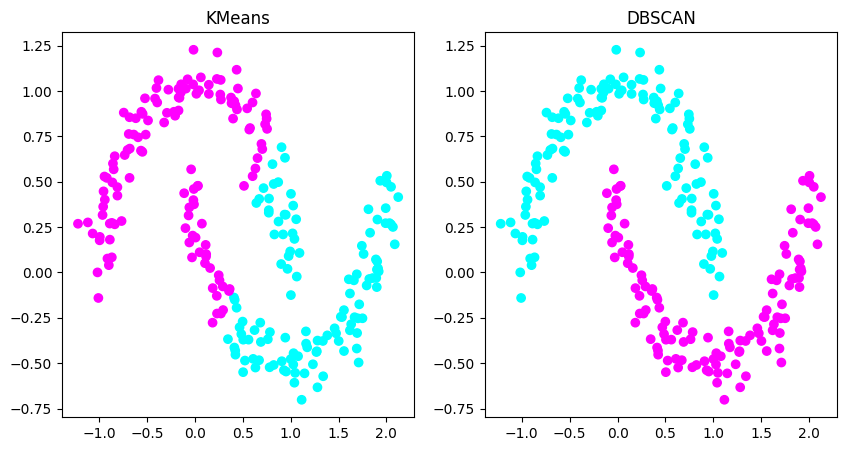

In [71]:
fig, axes = plt.subplots(1,2, figsize = (10,5))
                                            #옵션
axes[0].scatter(X[:,0], X[:,1], c=km_pred, cmap='cool')
axes[1].scatter(X[:,0], X[:,1], c=db_pred, cmap='cool')

axes[0].set_title('KMeans')
axes[1].set_title('DBSCAN')

plt.show()

# 가우시안